<div class="alert alert-block alert-info"> 
<h1><center> TSKS35: Information and Communications Engineering </center></h1>
<br>
<h2><center><font size="5">Laboratory Exercise 4: Digital Transmission through AWGN channels and Channel Coding</font></center></h2>
</div>




In this session, we will revisit the transmission of digital information over communication channels characterized as AWGN channels. To prepare for this session, please read sections 7.1 to 7.3 of the main book, and example 9.5.4.

### Digital modulations

Digital modulations allows to represent digital information in analog signal waveforms that can be transmitted through the channels. These waveforms can be geometrically represented as vectors in a space. The performance of different digital modulation methods are usually contrasted by using metrics such as bit error rate or symbol error rate.

In this session, we concentrate in one-dimensional and two-dimensional modulation schemes, for instance

- **Pulse amplitude modulation**. This is a one-dimensional modulation where information is conveyed by the amplitud of the transmitted signal. Binary information sequence can be subdivided into blocks of $k$ bits, called symbols, and each symbol is represented by one $M=2^k$ pulse amplitude values. In that case, it is called $M$-ary PAM. The one-dimensional vectors that represent $M$-ary PAM waveforms are given by

<center> $s_m=\sqrt{\mathcal{E}_g} A_m,$  $m=1,2,...M,$ </center>

 where $\mathcal{E}_g$ is the energy of the signal pulse. The distance between two signal points in the constellation is given by $\sqrt{\mathcal{E}_g (A_m-A_n)^2} $. If we select the signal amplitudes to be symetrically spaced about zero (i.e. $A_m=(2m-1-M)$) and equally distant between adjacent signal amplitudes, we call this symetric PAM.
   
- **Phase-shift keying**. This is a 2-dimensional modulation scheme. It modulates information by varying the phase of the carrier signal. The phase states are evenly spaced around a unit circle, and M indicates the number of distinct phases. The digital pahse-modulated signals can be represented geometrically as 2-dimensional vectors as

<center> $s_m=(\sqrt{\mathcal{E}_s} \cos 2 \pi m/M, \sqrt{\mathcal{E}_s} \sin 2 \pi m/M$) $\quad$  $m=0,1,...M,$ </center>

where $\mathcal{E}_s$ is the energy/symbol.

- **Quadrature amplitude modulation**. This is a 2-dimensional modulation scheme that combines both amplitude and phase modulation. The signal constellation is arranged in a grid-like pattern on the complex plane, with each point representing a unique combination of amplitude and phase. The 2-dimensional vectors  for QAM can be expressed in the form

<center> $s_m=(\sqrt{\mathcal{E}_s}  A_{mi}, \sqrt{\mathcal{E}_s} A_{mq}$ ) $\quad$ $mi/mq=1,2,...\sqrt{M},$ </center>

<div class="alert alert-block alert-success"> 
<font size="5"><span style="color:green"> Student task 1: Generation of constellations</span></font> 
   
1. Generate the constellations for 8-PAM, QPSK, 8-PSK, and 16-QAM. You can assume $\sqrt{\mathcal{E}_s}=\sqrt{\mathcal{E}_g}=1$
2. Apply Gray encoding, i.e., adjacent symbols (closest ones in the constellation) differ by one binary digit.
3. Plot the respective constellations

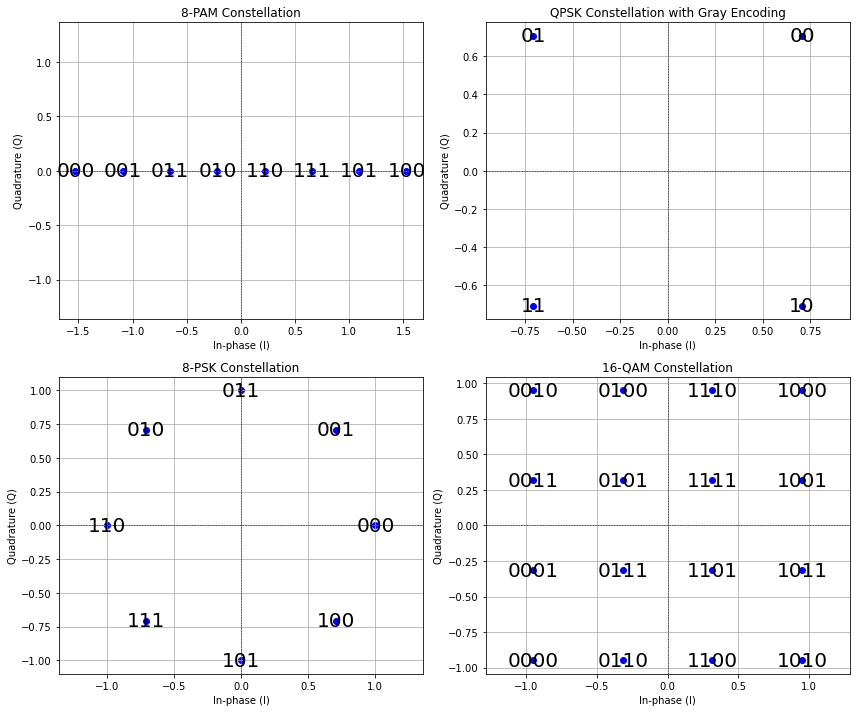

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Function to generate Gray code
def gray_code(n):
    if n == 0:
        return ['']
    first_half = gray_code(n - 1)
    second_half = first_half[::-1]
    return ['0' + code for code in first_half] + ['1' + code for code in second_half]

# Generate constellations
def generate_constellations():
    # 8-PAM (1D constellation)
    M_pam = 8
    pam_symbols = np.linspace(-7, 7, M_pam) / np.sqrt(np.mean(np.square(np.linspace(-7, 7, M_pam))))
    pam_gray = gray_code(3)  # 3 bits for 8 levels

    # QPSK (2D constellation)
    qpsk_symbols = [1 + 1j, -1 + 1j, -1 - 1j, 1 - 1j]
    qpsk_symbols = [s / np.sqrt(2) for s in qpsk_symbols]  # Normalize to unit energy
    qpsk_gray = gray_code(2)  # 2 bits for 4 levels

    # 8-PSK (2D constellation)
    M_psk = 8
    psk_symbols = [np.exp(1j * 2 * np.pi * i / M_psk) for i in range(M_psk)]
    psk_gray = gray_code(3)  # 3 bits for 8 levels

    # 16-QAM (2D constellation)
    levels = np.linspace(-3, 3, 4)
    qam_symbols = [x + 1j * y for x in levels for y in levels]
    qam_symbols /= np.sqrt(np.mean(np.abs(qam_symbols) ** 2))  # Normalize energy
    qam_gray = gray_code(4)  # 4 bits for 16 levels

    return pam_symbols, pam_gray, qpsk_symbols, qpsk_gray, psk_symbols, psk_gray, qam_symbols, qam_gray

# Plot constellations
def plot_constellation(ax, symbols, title, gray_labels):
    ax.scatter(np.real(symbols), np.imag(symbols), color='blue')
    for i, symbol in enumerate(symbols):
        ax.text(np.real(symbol), np.imag(symbol), gray_labels[i], fontsize=20, ha='center', va='center', color='black')
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_title(title)
    ax.grid(True)
    ax.set_xlabel("In-phase (I)")
    ax.set_ylabel("Quadrature (Q)")
    ax.axis('equal')

# Main function to generate and plot constellations
def main():
    pam_symbols, pam_gray, qpsk_symbols, qpsk_gray, psk_symbols, psk_gray, qam_symbols, qam_gray = generate_constellations()

    # Plot all constellations in subplots
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Plot each constellation
    plot_constellation(axes[0, 0], pam_symbols, "8-PAM Constellation", pam_gray)
    plot_constellation(axes[0, 1], qpsk_symbols, "QPSK Constellation with Gray Encoding", qpsk_gray)
    plot_constellation(axes[1, 0], psk_symbols, "8-PSK Constellation", psk_gray)
    plot_constellation(axes[1, 1], qam_symbols, "16-QAM Constellation", qam_gray)

    # Adjust layout
    plt.tight_layout()

    # Display the plot
    plt.show()

# Run the program
if __name__ == "__main__":
    main()


### AWGN channel

The channel is assumed to corrupt the signal by the addition of white Gaussian noise. Thus, the received signal in the interval $0\leq t \leq T$ may be expressed as

<center> $r(t)=s_m(t)+n(t)$, $\quad$ $0\leq t \leq T$ </center>

<div class="alert alert-block alert-success"> 
<font size="5"><span style="color:green"> Student task 2: Signal transmission through AWGN channel</span></font>

Complete the code snippet below for each modulation scheme of Student task 1
1. Randomly generate $10^6$ symbols to be transmitted.
2. Generate $n(t)$.
3. Obtain $r(t)$.
4. Plot the received symbols on the space (noisy constellation).
5. Apply the optimum dectector (minimum distance detector) and obtain the detected symbols.
6. Plot the curves of symbol error rate and bit error rate for the different modultaions for different values of SNR.

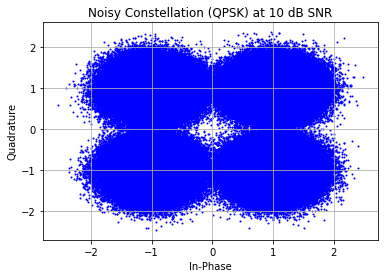

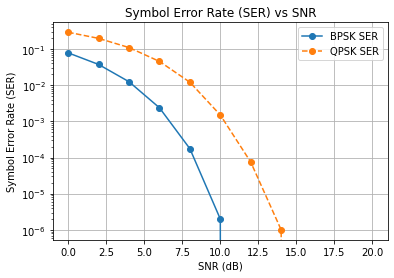

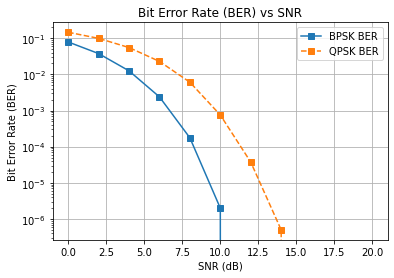

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 10**6  # Number of symbols
SNR_dB_range = np.arange(0, 21, 2)  # SNR range in dB

SER_results = {"BPSK": [], "QPSK": []}
BER_results = {"BPSK": [], "QPSK": []}

# Define constellation points for BPSK and QPSK
constellations = {
    "BPSK": np.array([-1, 1]),
    "QPSK": np.array([-1-1j, -1+1j, 1-1j, 1+1j])
}

# Simulation for BPSK and QPSK
for modulation in ["BPSK", "QPSK"]:
    constellation_points = constellations[modulation]
    M = len(constellation_points)  # Number of constellation points
    bits_per_symbol = int(np.log2(M))

    for SNR_dB in SNR_dB_range:
        # Step 1: Randomly generate symbols to be transmitted
        symbol_indices = np.random.randint(0, M, N)
        transmitted_symbols = constellation_points[symbol_indices]

        # Step 2: Generate AWGN noise
        SNR_linear = 10**(SNR_dB / 10)
        signal_power = np.mean(np.abs(transmitted_symbols)**2)
        noise_power = signal_power / SNR_linear
        noise = np.sqrt(noise_power / 2) * (np.random.randn(N) + 1j * np.random.randn(N))

        # Step 3: Obtain received symbols
        received_symbols = transmitted_symbols + noise

        # Step 4: Plot the received symbols on the space (noisy constellation) for a specific SNR
        if modulation == "QPSK" and SNR_dB == 10:  # Adjust this condition to plot for different cases
            plt.scatter(received_symbols.real, received_symbols.imag, color='blue', s=1)
            plt.title(f'Noisy Constellation ({modulation}) at {SNR_dB} dB SNR')
            plt.xlabel('In-Phase')
            plt.ylabel('Quadrature')
            plt.grid(True)
            plt.show()

        # Step 5: Apply the optimum detector (minimum distance detector)
        detected_idx = np.zeros(N, dtype=int)
        for i, r in enumerate(received_symbols):
            distances = np.abs(constellation_points - r)
            detected_idx[i] = np.argmin(distances)
        detected_symbols = constellation_points[detected_idx]

        # Calculate Symbol Error Rate (SER) and Bit Error Rate (BER)
        SER = np.mean(transmitted_symbols != detected_symbols)
        BER = SER / bits_per_symbol
        SER_results[modulation].append(SER)
        BER_results[modulation].append(BER)

# Step 6: Plot the Symbol Error Rate (SER) curves for different values of SNR
plt.figure()
plt.plot(SNR_dB_range, SER_results["BPSK"], 'o-', label='BPSK SER')
plt.plot(SNR_dB_range, SER_results["QPSK"], 'o--', label='QPSK SER')
plt.title('Symbol Error Rate (SER) vs SNR')
plt.xlabel('SNR (dB)')
plt.ylabel('Symbol Error Rate (SER)')
plt.yscale('log')
plt.grid(True)
plt.legend()
plt.show()

# Step 7: Plot the Bit Error Rate (BER) curves for different values of SNR
plt.figure()
plt.plot(SNR_dB_range, BER_results["BPSK"], 's-', label='BPSK BER')
plt.plot(SNR_dB_range, BER_results["QPSK"], 's--', label='QPSK BER')
plt.title('Bit Error Rate (BER) vs SNR')
plt.xlabel('SNR (dB)')
plt.ylabel('Bit Error Rate (BER)')
plt.yscale('log')
plt.grid(True)
plt.legend()
plt.show()

### Channel coding

Channel coding consists on selectively introducing redundant bits to improve robustness agains errors due to channel impairments, for instance, noise. In linear block codes, the information sequence is broken into blocks of length $k$ and each block is mapped into channel inputs of length $n$. Hamming codes are a class of linear block codes with $n=2^m-1$, $k=2^m -m-1$, and $d_{min}=3$, for some integer $m\geq2$.


<div class="alert alert-block alert-success"> 
<font size="5"><span style="color:green"> Student task 3: Channel coding</span></font>

1. Generate random information bits ($4\times 10^6$) and store in the variable -data-.
2. Check Example 9.5.4 of the book and the code snippet below, and apply Hamming code (7,4) to the information bits.
3. Apply QPSK or 4-QAM modulation to the coded information.
4. Transmit over an AWGN channel.
5. Decode with hard-decision decoding.
6. Compare the bit error rate of coded and non-coded transmission.

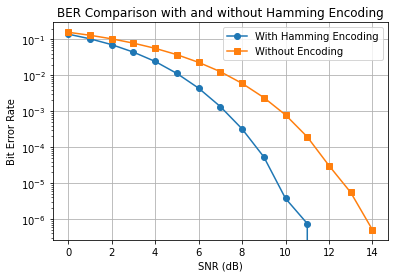

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Generate random information bits
data = np.random.randint(0, 2, 4 * 10**6)

# Apply Hamming coding
def hamming_encode(data):
   if len(data) % 4 != 0:
       raise ValueError("Input data length should be multiple of 4.")
   G = [[1, 0, 0, 1, 0, 1, 1],
        [0, 1, 0, 1, 0, 1, 0],
        [0, 0, 1, 1, 0, 0, 1],
        [0, 0, 0, 0, 1, 1, 1]]
   encoded_data = []
   for k in range(0, len(data), 4):
       block = data[k:k+4]
       for i in range(7):
           sum = 0
           for j in range(4):
               sum += block[j] * G[j][i]
           encoded_data.append(sum % 2)
   return encoded_data

encoded_data = hamming_encode(data)

# Modulate with QPSK or 4-QAM
def qpsk_modulate(data):
   data = np.array(data)
   data = data.reshape((-1, 2))
   symbols = (2*data[:,0] - 1) + 1j*(2*data[:,1] - 1)
   return symbols

modulated_data = qpsk_modulate(encoded_data)

# Transmit symbols through AWGN channel
def awgn_channel(symbols, snr_dB):
   snr_linear = 10**(snr_dB / 10)
   signal_power = np.mean(np.abs(symbols)**2)
   noise_power = signal_power / snr_linear
   noise = np.sqrt(noise_power / 2) * (np.random.randn(len(symbols)) + 1j * np.random.randn(len(symbols)))
   received_symbols = symbols + noise
   return received_symbols

snr_dbs = np.arange(0, 15)
ber_encoded = []
ber_plain = []

for snr_dB in snr_dbs:
   # Transmit encoded symbols
   received_symbols_encoded = awgn_channel(modulated_data, snr_dB)

   # Decode symbols with hard-decision decoding
   def qpsk_demodulate(symbols):
       demod_bits = np.zeros((len(symbols), 2))
       demod_bits[:,0] = np.real(symbols) > 0
       demod_bits[:,1] = np.imag(symbols) > 0
       return demod_bits.flatten().astype(int)

   def hamming_decode(received_data):
       if len(received_data) % 7 != 0:
           raise ValueError("Received data length should be multiple of 7.")
       H = [[1, 0, 1, 0, 1, 0, 1],
            [1, 1, 0, 0, 1, 1, 0],
            [1, 1, 1, 1, 0, 0, 0]]
       decoded_data = []
       for k in range(0, len(received_data), 7):
           block = received_data[k:k+7]
           syndrome = []
           for i in range(3):
               syndrome_sum = 0
               for j in range(7):
                   syndrome_sum += block[j] * H[i][j]
               syndrome.append(syndrome_sum % 2)
           error_pos = sum([2 ** i for i, bit in enumerate(syndrome) if bit])
           if error_pos > 0:
               block[7-error_pos] ^= 1  
           decoded_data.extend([block[0], block[1], block[2], block[4]])
       return decoded_data

   demodulated_bits_encoded = qpsk_demodulate(received_symbols_encoded)
   decoded_bits_encoded = hamming_decode(demodulated_bits_encoded)

   # Calculate BER for encoded transmission
   errors_encoded = np.sum(data != decoded_bits_encoded[:len(data)])
   ber_encoded.append(errors_encoded / len(data))

   # Transmit plain (non-coded) symbols
   modulated_data_plain = qpsk_modulate(data)
   received_symbols_plain = awgn_channel(modulated_data_plain, snr_dB)
   
   # Demodulate plain symbols
   demodulated_bits_plain = qpsk_demodulate(received_symbols_plain)

   # Calculate BER for plain transmission
   errors_plain = np.sum(data != demodulated_bits_plain[:len(data)])
   ber_plain.append(errors_plain / len(data))

# Plot bit error rate and compare the performance of coded and non-coded transmission.
plt.figure()
plt.semilogy(snr_dbs, ber_encoded, 'o-', label='With Hamming Encoding')
plt.semilogy(snr_dbs, ber_plain, 's-', label='Without Encoding')
plt.title('BER Comparison with and without Hamming Encoding')
plt.xlabel('SNR (dB)')
plt.ylabel('Bit Error Rate')
plt.legend()
plt.grid(True)
plt.show()

<div class="alert alert-block alert-info"> 
<h2><center> Report of Laboratory Excercise 4</center></h2>
<br>

Answer the following questions supporting your claims with formulations and plots obtained from the Student Tasks. Add your codes at the end of the final report as appendix.
    
__NOTE:__ You should prepare these questions up to the next laboratory session. Teaching assistants will verify your progress during next session. Final report should be uploaded to Lisam in pdf format according to laboratory guidelines. 
    
1. What are the difference between one- and two-dimensional modulations? What is the difference between amplitude and phase modulations? Observe and describe the constellations. (1pt).
2. What is the purpose of Gray encoding? What is the difference between symbol error rate and bit error rate after applying Gray coding? (1pt)
3. Comment on the difference on the symbol error rate for different modulation schemes, what are the advantages and disadvantages of those? (2pt)
4. What is the purpose of channel coding? (1pt)
</div>